Preprocessing notebook. Here, I'll clean the dataset from missing values and I will prepare the pipeline for generating the dataset for the ML model

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [49]:
import os

# -----------------------------------------------------
# comment if using on local instead of Google Drive:
if os.path.exists("/content/drive/MyDrive"):
  print("drive is already mounted")
else:
  print("Drive is not yet mounted")
  from google.colab import drive
  drive.mount('/content/drive')
# -----------------------------------------------------

# change with your own directory
os.chdir('/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project')

drive is already mounted


In [6]:
# change with your own directory
folder = "/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project/"

dataFrameName = folder + "data/diabetes_1.csv"
dataframe = pd.read_csv(dataFrameName , index_col = 'id')

In [7]:
dataframe.head(10)

,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
id,,,,,,,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
1008,248.0,94,69.0,3.6,4.81,Buckingham,34,male,71.0,190.0,large,132.0,86.0,NaN,NaN,36.0,42.0,195.0
1011,195.0,92,41.0,4.8,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
1015,227.0,75,44.0,5.2,3.94,Buckingham,37,male,59.0,170.0,medium,NaN,NaN,NaN,NaN,34.0,39.0,1020.0
1016,177.0,87,49.0,3.6,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0


DATASET PRE-CLEANING

In [8]:
dataframe.isna().sum()

,0
chol,1
stab.glu,0
hdl,1
ratio,1
glyhb,13
location,0
age,0
gender,0
height,5
weight,1


In [9]:
clean_df = dataframe.drop(columns=["bp.2s", "bp.2d", "time.ppn", "location"],
                           errors="ignore")

# second check of blood pressure is a ill-posed feature
# time post-prandial is not a relevant parameter
# I don't think location is a key parameter

In [10]:
clean_df = clean_df.drop( clean_df[clean_df["glyhb"].isna()].index )

# rows without the target variables should be deleted

In [11]:
clean_df.isna().sum()

,0
chol,1
stab.glu,0
hdl,1
ratio,1
glyhb,0
age,0
gender,0
height,5
weight,1
frame,11


In [12]:
# fix units of measure
clean_df["weight"] = clean_df["weight"]* 0.453592 # from pound to kg
clean_df["height"], clean_df["waist"], clean_df["hip"] = clean_df["height"]*0.0254, clean_df["waist"]* 0.0254, clean_df["hip"]* 0.0254  # from inches to m

In [13]:
clean_df

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip
id,,,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.310000,46,female,1.5748,54.884632,medium,118.0,59.0,0.7366,0.9652
1001,165.0,97,24.0,6.9,4.440000,29,female,1.6256,98.883056,large,112.0,68.0,1.1684,1.2192
1002,228.0,92,37.0,6.2,4.640000,58,female,1.5494,116.119552,large,190.0,92.0,1.2446,1.4478
1003,78.0,93,12.0,6.5,4.630000,67,male,1.7018,53.977448,large,110.0,50.0,0.8382,0.9652
1005,249.0,90,28.0,8.9,7.720000,64,male,1.7272,83.007336,medium,138.0,80.0,1.1176,1.0414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41503,301.0,90,118.0,2.6,4.280000,89,female,1.5494,52.163080,medium,218.0,90.0,0.7874,1.0414
41506,296.0,369,46.0,6.4,16.110001,53,male,1.7526,78.471416,medium,138.0,94.0,0.8890,0.9906
41507,284.0,89,54.0,5.3,4.390000,51,female,1.6002,69.853168,medium,140.0,100.0,0.8128,1.0922


TRAIN-TEST SPLIT

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = clean_df.drop(columns=['glyhb'])
y = clean_df['glyhb']

# dataset splitting target - features

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None)   # 42

# train test splitting

FEATURE ENGINEERING

In [17]:
X_combined = pd.concat([X_train, X_test])
y_combined = pd.concat([y_train, y_test])

X_combined["bmi"] = X_combined['weight']/X_combined['height']**2 # body mass index
X_combined["absi"] = X_combined['waist']/(X_combined["bmi"]**(2.0/3.0) * X_combined['height']**0.5)
X_combined["map"] = X_combined['bp.1d'] + ((X_combined['bp.1s'] - X_combined['bp.1d'])/3.0) # mean arterial pressure
X_combined["pp"] = X_combined['bp.1s'] - X_combined['bp.1d'] #  pulse pressure
X_combined["whr"] = X_combined['waist']/X_combined['hip']  # waist to hip ratio
X_combined["age_square"] = X_combined['age']**2 # age square

X_combined['age_x_ratio'] = X_combined['age'] * X_combined['ratio']


X_combined["age_group"] = pd.cut(
    X_combined["age"],
    bins=[0, 30, 60, float("inf")],
    labels=["young", "middle", "old"],
    right=False
)

X_combined["log_glu"] = np.log1p(X_combined["stab.glu"])
X_combined.drop(columns=['stab.glu'], inplace=True)

X_train = X_combined.loc[X_train.index]
X_test = X_combined.loc[X_test.index]

y_combined= np.log1p(y_combined)

y_train = y_combined.loc[y_train.index]
y_test = y_combined.loc[y_test.index]

y_train.name = "log_hb"
y_test.name = "log_hb"

In [18]:
# X_train["log_glu"].plot(kind='hist', bins=20)
# X_test["log_glu"].plot(kind='hist', bins=20)

In [19]:
# y_train.plot(kind='hist', bins=20)
# y_test.plot(kind='hist', bins=20)

OHE for gender and frame

In [20]:
X_combined = pd.concat([X_train, X_test])
X_combined_encoded = pd.get_dummies(X_combined, columns=['frame', 'gender', 'age_group'], drop_first=True)

# one-hot encoding of gender and frame
# This is a first test. maybe ordinal encoding is more accurate

In [21]:
X_train_enc = X_combined_encoded.loc[X_train.index]
X_test_enc = X_combined_encoded.loc[X_test.index]

In [22]:
X_train_enc

,chol,hdl,ratio,age,height,weight,bp.1s,bp.1d,waist,hip,...,pp,whr,age_square,age_x_ratio,log_glu,frame_medium,frame_small,gender_male,age_group_middle,age_group_old
id,,,,,,,,,,,,,,,,,,,,,
20332,178.0,52.0,3.4,41,1.6510,85.275296,130.0,76.0,0.8890,1.1684,...,54.0,0.760870,1681,139.400004,4.174387,False,True,False,True,False
2787,223.0,85.0,2.6,22,1.5748,62.142104,120.0,70.0,0.7112,0.8890,...,50.0,0.800000,484,57.199998,4.330733,True,False,False,False,False
17776,201.0,46.0,4.4,27,1.6510,65.770840,121.0,75.0,0.8128,0.8890,...,46.0,0.914286,729,118.800003,4.615121,False,True,False,False,False
40784,226.0,52.0,4.3,84,1.5240,87.089664,144.0,88.0,1.0414,1.2192,...,56.0,0.854167,7056,361.200016,5.634790,False,True,False,False,True
16001,222.0,87.0,2.6,51,1.6764,49.895120,150.0,110.0,0.7112,0.9398,...,40.0,0.756757,2601,132.599995,4.418841,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,204.0,74.0,2.8,52,1.9050,64.410064,140.0,90.0,0.7874,0.8890,...,50.0,0.885714,2704,145.599998,4.060443,False,True,True,True,False
4813,244.0,36.0,6.8,32,1.7780,96.161504,132.0,90.0,0.9906,1.1176,...,42.0,0.886364,1024,217.600006,4.624973,False,False,True,True,False
20274,181.0,44.0,4.1,29,1.7272,81.646560,130.0,78.0,0.9652,1.0668,...,52.0,0.904762,841,118.899997,4.624973,True,False,True,False,False


PIPELINE: IMPUTATION + SCALING

In [23]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [24]:
preprocessing_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    # ('scaler', StandardScaler())              # standard scaler just for test
    ('scaler', RobustScaler())
])

# I guess robust scaler is generally better (see EDA file)

In [25]:
X_train_processed = preprocessing_pipeline.fit_transform(X_train_enc) # it produce a numpy array
X_test_processed = preprocessing_pipeline.transform(X_test_enc) # it produce a numpy array

In [26]:
# revert this to pandas df:
X_train_pp = pd.DataFrame(X_train_processed, columns=X_train_enc.columns, index=X_train_enc.index)
X_test_pp = pd.DataFrame(X_test_processed, columns=X_test_enc.columns, index=X_test_enc.index)

In [27]:
print("NaN values in the initial TRAIN dataset:", pd.isnull(X_train).sum().sum())
print("NaN values in the initial TEST dataset:", pd.isnull(X_test).sum().sum())
print("X_train initial Dimensions:", X_train.shape)
print("X_test initial Dimensions:", X_test.shape)

NaN values in the initial TRAIN dataset: 54
NaN values in the initial TEST dataset: 7
X_train initial Dimensions: (312, 21)
X_test initial Dimensions: (78, 21)


In [28]:
print("NaN values in the final TRAIN dataset:", pd.isnull(X_train_pp).sum().sum())
print("NaN values in the final TEST dataset:", pd.isnull(X_test_pp).sum().sum())
print("X_train final Dimensions:", X_train_pp.shape)
print("X_test final Dimensions:", X_test_pp.shape)

# as expected

NaN values in the final TRAIN dataset: 0
NaN values in the final TEST dataset: 0
X_train final Dimensions: (312, 23)
X_test final Dimensions: (78, 23)


SOME CHECKS:

In [29]:
X_train_pp

,chol,hdl,ratio,age,height,weight,bp.1s,bp.1d,waist,hip,...,pp,whr,age_square,age_x_ratio,log_glu,frame_medium,frame_small,gender_male,age_group_middle,age_group_old
id,,,,,,,,,,,,,,,,,,,,,
20332,-0.507463,0.285714,-0.363636,-0.115385,-0.166667,0.290155,-0.225989,-0.400000,-0.413793,0.500,...,0.197531,-1.192191,-0.104337,-0.355713,-1.116396,0.0,1.0,0.0,0.0,0.0
2787,0.388060,1.857143,-0.727273,-0.846154,-0.666667,-0.766839,-0.602637,-0.800000,-1.379310,-0.875,...,0.000000,-0.783439,-0.594108,-0.938175,-0.560964,1.0,0.0,0.0,-1.0,0.0
17776,-0.049751,0.000000,0.090909,-0.653846,-0.166667,-0.601036,-0.564972,-0.466667,-0.827586,-0.875,...,-0.197531,0.410373,-0.493863,-0.501683,0.449345,0.0,1.0,0.0,-1.0,0.0
40784,0.447761,0.285714,0.045455,1.538462,-1.000000,0.373057,0.301318,0.400000,0.413793,0.750,...,0.296296,-0.217622,2.094926,1.215943,4.071805,0.0,1.0,0.0,-1.0,1.0
16001,0.368159,1.952381,-0.727273,0.269231,0.000000,-1.326425,0.527307,1.866667,-1.379310,-0.625,...,-0.493827,-1.235152,0.272095,-0.403897,-0.247955,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3752,0.009950,1.333333,-0.636364,0.307692,1.500000,-0.663212,0.150659,0.533333,-0.965517,-0.875,...,0.000000,0.111920,0.314239,-0.311780,-1.521193,0.0,1.0,1.0,0.0,0.0
4813,0.805970,-0.476190,1.181818,-0.461538,0.666667,0.787565,-0.150659,0.533333,0.137931,0.250,...,-0.395062,0.118703,-0.373159,0.198406,0.484347,0.0,0.0,1.0,0.0,0.0
20274,-0.447761,-0.095238,-0.045455,-0.576923,0.333333,0.124352,-0.225989,-0.266667,0.000000,0.000,...,0.098765,0.310889,-0.448036,-0.500974,0.484347,1.0,0.0,1.0,-1.0,0.0


In [30]:
nbin = 20

<Axes: ylabel='Frequency'>

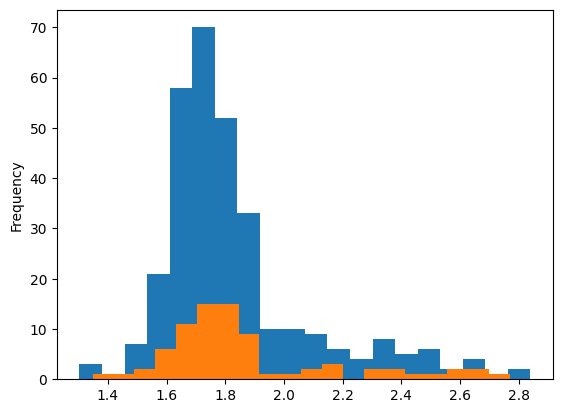

In [31]:
y_train.plot(kind='hist', bins=nbin)
y_test.plot(kind='hist', bins=nbin)

<Axes: ylabel='Frequency'>

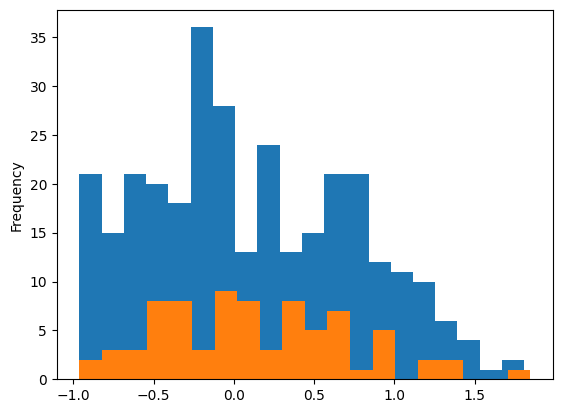

In [32]:
X_train_pp["age"].plot(kind='hist', bins=nbin)
X_test_pp["age"].plot(kind='hist', bins=nbin)

<Axes: ylabel='Frequency'>

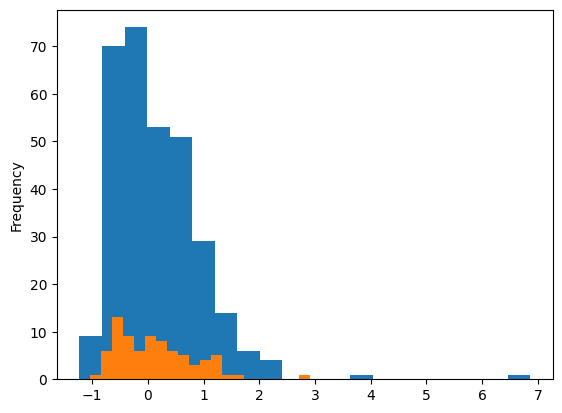

In [33]:
X_train_pp["ratio"].plot(kind='hist', bins=nbin)
X_test_pp["ratio"].plot(kind='hist', bins=nbin)

<Axes: ylabel='Frequency'>

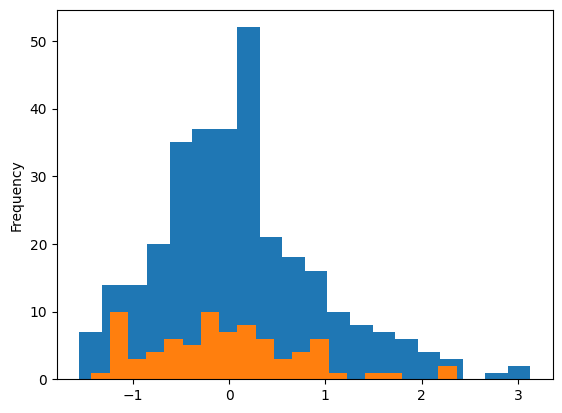

In [34]:
X_train_pp["weight"].plot(kind='hist', bins=nbin)
X_test_pp["weight"].plot(kind='hist', bins=nbin)

<Axes: ylabel='Frequency'>

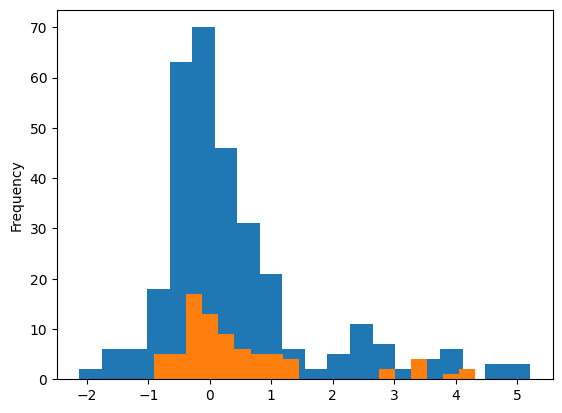

In [35]:
X_train_pp["log_glu"].plot(kind='hist', bins=nbin)
X_test_pp["log_glu"].plot(kind='hist', bins=nbin)

Last Check

In [36]:
X_train_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 20332 to 4801
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chol              312 non-null    float64
 1   hdl               312 non-null    float64
 2   ratio             312 non-null    float64
 3   age               312 non-null    float64
 4   height            312 non-null    float64
 5   weight            312 non-null    float64
 6   bp.1s             312 non-null    float64
 7   bp.1d             312 non-null    float64
 8   waist             312 non-null    float64
 9   hip               312 non-null    float64
 10  bmi               312 non-null    float64
 11  absi              312 non-null    float64
 12  map               312 non-null    float64
 13  pp                312 non-null    float64
 14  whr               312 non-null    float64
 15  age_square        312 non-null    float64
 16  age_x_ratio       312 non-null    float64
 1

In [37]:
X_test_pp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78 entries, 1022 to 21359
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chol              78 non-null     float64
 1   hdl               78 non-null     float64
 2   ratio             78 non-null     float64
 3   age               78 non-null     float64
 4   height            78 non-null     float64
 5   weight            78 non-null     float64
 6   bp.1s             78 non-null     float64
 7   bp.1d             78 non-null     float64
 8   waist             78 non-null     float64
 9   hip               78 non-null     float64
 10  bmi               78 non-null     float64
 11  absi              78 non-null     float64
 12  map               78 non-null     float64
 13  pp                78 non-null     float64
 14  whr               78 non-null     float64
 15  age_square        78 non-null     float64
 16  age_x_ratio       78 non-null     float64
 17

In [38]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 312 entries, 20332 to 4801
Series name: log_hb
Non-Null Count  Dtype  
--------------  -----  
312 non-null    float64
dtypes: float64(1)
memory usage: 4.9 KB


In [39]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 78 entries, 1022 to 21359
Series name: log_hb
Non-Null Count  Dtype  
--------------  -----  
78 non-null     float64
dtypes: float64(1)
memory usage: 1.2 KB


INFINE SALVO I SUBSETS

In [40]:
import joblib

joblib.dump(
    {
        "X_train": X_train_pp,
        "X_test": X_test_pp,
        "y_train": y_train,
        "y_test": y_test,
    },
    "data/preprocessed_dataset.joblib"
)

['data/preprocessed_dataset.joblib']

EDA - post feature engineering

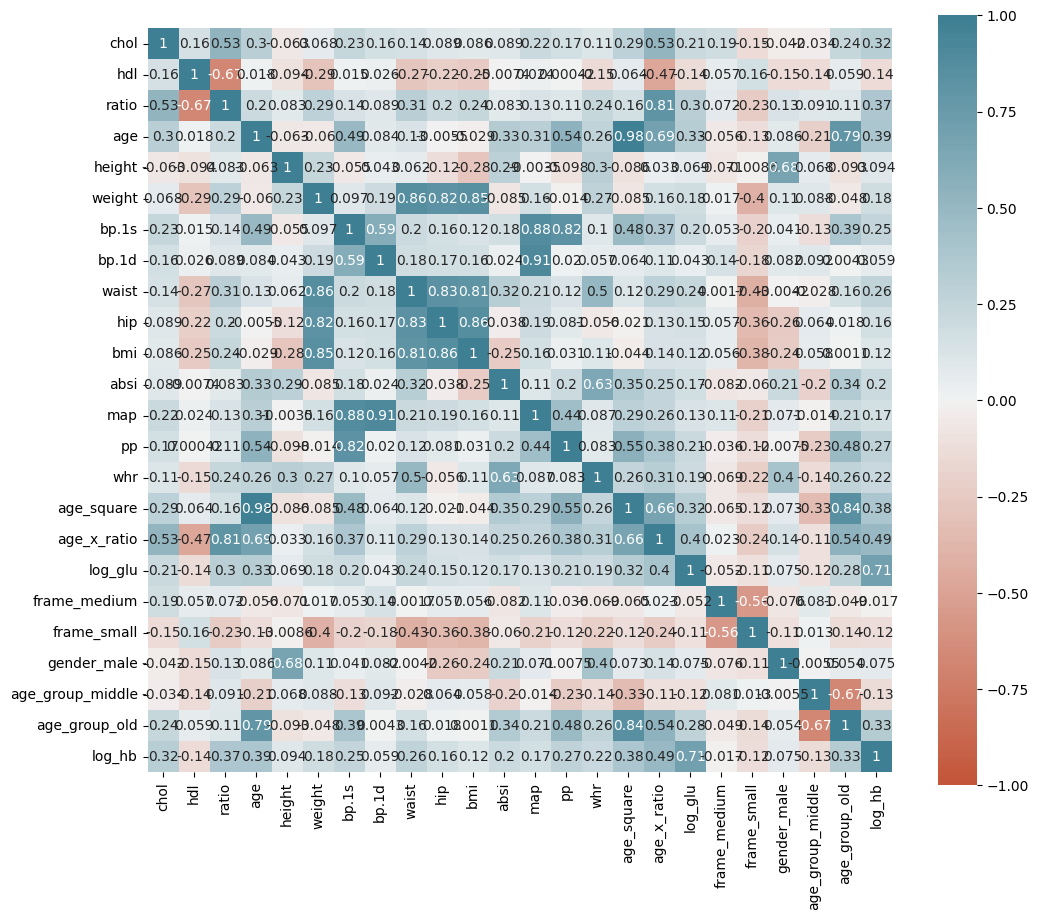

In [41]:
df_train = X_train_pp.join(y_train)
corrMatrix = df_train.corr() # only numerical variables

plt.figure(figsize=(12,10))
sns.heatmap(corrMatrix,  vmin=-1, vmax = 1, center = 0,
            cmap = sns.diverging_palette(20,220, n=200),
            annot=True, square = True)
plt.show()

surplisely, we obtain a better correlation score for age_x_ratio feature

In [42]:
# variance inflation Factor (VIF): multi-collinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X): # X: the data frame
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif.sort_values(by=['VIF'], ascending = True)
    return(vif)

calc_vif(df_train.drop(columns=['log_hb']))  # no target variable

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variables,VIF
0,chol,4.552207
1,hdl,5.816429
2,ratio,23.041641
3,age,91.893472
4,height,11.442294
5,weight,61.042190
6,bp.1s,inf
7,bp.1d,inf
8,waist,303.225154
9,hip,201.332811


In [43]:
df_train = df_train.drop(columns=["bp.1s", "bp.1d"])

In [44]:
calc_vif(df_train.drop(columns=['log_hb'])).sort_values(by=['VIF'], ascending = True)

,variables,VIF
15,log_glu,1.378179
10,map,1.427092
11,pp,1.777930
17,frame_small,2.461884
16,frame_medium,3.050265
18,gender_male,3.875460
0,chol,4.505476
1,hdl,5.983500
19,age_group_middle,11.142247
4,height,11.144217


In [45]:
df_train = df_train.drop(columns=["waist", "hip"])
calc_vif(df_train.drop(columns=['log_hb'])).sort_values(by=['VIF'], ascending = False)

,variables,VIF
3,age,93.381237
11,age_square,81.969944
6,bmi,30.714524
5,weight,30.063555
12,age_x_ratio,29.755902
2,ratio,21.997488
18,age_group_old,14.057008
17,age_group_middle,10.979846
4,height,9.911530
1,hdl,5.634885


In [46]:
df_train = df_train.drop(columns=["age", "age_square"])
calc_vif(df_train.drop(columns=['log_hb'])).sort_values(by=['VIF'], ascending = False)

,variables,VIF
5,bmi,30.620482
4,weight,29.975397
2,ratio,14.263105
10,age_x_ratio,12.613988
3,height,9.700737
16,age_group_old,8.936383
1,hdl,5.345291
15,age_group_middle,4.555554
0,chol,4.042836
14,gender_male,2.926613


In [47]:
df_train = df_train.drop(columns=["bmi", "weight"])
calc_vif(df_train.drop(columns=['log_hb'])).sort_values(by=['VIF'], ascending = False)

,variables,VIF
2,ratio,13.534700
8,age_x_ratio,11.994261
14,age_group_old,8.663944
1,hdl,5.338123
13,age_group_middle,4.536237
0,chol,4.011724
12,gender_male,2.880534
7,whr,2.182535
4,absi,2.022219
3,height,1.958822


In [48]:
df_train = df_train.drop(columns=["ratio"])
calc_vif(df_train.drop(columns=['log_hb'])).sort_values(by=['VIF'], ascending = False)

,variables,VIF
7,age_x_ratio,6.276879
13,age_group_old,6.177473
12,age_group_middle,3.803784
1,hdl,2.984223
11,gender_male,2.831679
0,chol,2.466968
6,whr,2.165037
3,absi,2.006773
2,height,1.957544
5,pp,1.701921
